# Setup

In [15]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

print("Added to PYTHONPATH:", PROJECT_ROOT)

Added to PYTHONPATH: c:\Users\yfess\Desktop\timeseries-thesis


In [16]:
from dotenv import load_dotenv
import os

env_file = PROJECT_ROOT / ".env"
print(env_file.exists())
load_dotenv(env_file)
print("Loaded env file:", env_file)

True
Loaded env file: c:\Users\yfess\Desktop\timeseries-thesis\.env


In [17]:
from src.common.config import load_config
from src.common.logger import get_logger
from src.databases.benchmark_db.config import get_postgres_config
from src.databases.benchmark_db.benchmark_db import BenchmarkDB

benchmarkdb_config_file_path = PROJECT_ROOT / "configs/config-benchmarkdb.yml"
benchmarkdb_config_dict = load_config(benchmarkdb_config_file_path)

logger = get_logger("benchmark_db", benchmarkdb_config_dict["general"]["log_file"])
benchmarkdb_config = get_postgres_config(benchmarkdb_config_dict["database"])
benchmarkdb_repo = BenchmarkDB(benchmarkdb_config, logger)

try:
    benchmarkdb_repo.connect()
    print("Connected to BenchmarkDB successfully.")
except Exception as e:
    print("Failed to connect to BenchmarkDB:", e)

Connected to BenchmarkDB successfully.


# Load Results

In [18]:
read_latest_ALL = benchmarkdb_repo.get_all_read_latest_benchmark_results()
len(read_latest_ALL)

150

In [19]:
one_r = read_latest_ALL[0]
print(one_r)

ReadLatestBenchmarkResult 1526
  benchmark:          read.latest_value
  database system:    influxdb
  database version:   2.7
  parameter:          sea_water_temperature
  result found:       True
  elapsed time:       1.238709 s
  elapsed time ns:    1238708600 ns
  created at:         2026-08-14T13:41:14.384565+00:00


# Partition

In [20]:
from collections import defaultdict

db_results = defaultdict(list)
for r in read_latest_ALL:
    db_results[r.database_system].append(r)

db_systems = sorted(db_results.keys())
db_systems

['influxdb', 'mongodb', 'timescaledb']

In [21]:
DB_COLOR_MAP = {
    'mongodb':     '#00ED64',
    'influxdb':    '#F18F13',
    'timescaledb': '#0064FF',
    'questdb':     '#FF5733',
}
DB_COLORS = ['#00ED64', '#F18F13', '#0064FF', '#FF5733', '#A855F7', '#EC4899']

db_color = {
    db: DB_COLOR_MAP.get(db, DB_COLORS[i % len(DB_COLORS)])
    for i, db in enumerate(db_systems)
}
db_color

{'influxdb': '#F18F13', 'mongodb': '#00ED64', 'timescaledb': '#0064FF'}

# Analysis

In [22]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# DataFrame

In [23]:
rows = []
for db in db_systems:
    for r in db_results[db]:
        rows.append({
            'database_system': db,
            'parameter': r.parameter,
            'result_found': r.result_found,
            'elapsed_ns': r.elapsed_time_ns,
            'elapsed_ms': r.elapsed_time_ns / 1_000_000,
        })

df = pd.DataFrame(rows)
df.head()

,database_system,parameter,result_found,elapsed_ns,elapsed_ms
0,influxdb,sea_water_temperature,True,1238708600,1238.7086
1,influxdb,sea_water_temperature,True,422900200,422.9002
2,influxdb,sea_water_temperature,True,341186800,341.1868
3,influxdb,sea_water_temperature,True,273544600,273.5446
4,influxdb,sea_water_temperature,True,272566800,272.5668


## Mean Latency per Database (across all parameters and repeats)

In [24]:
summary_df = df.groupby('database_system')['elapsed_ms'].agg(['mean', 'std', 'min', 'max', 'count'])
summary_df = summary_df.reindex(db_systems)
summary_df

,mean,std,min,max,count
database_system,,,,,
influxdb,194.414714,169.284698,79.1532,1238.7086,50
mongodb,11.938026,15.337593,6.3974,114.1579,50
timescaledb,279.919562,475.033659,127.4242,3505.1877,50


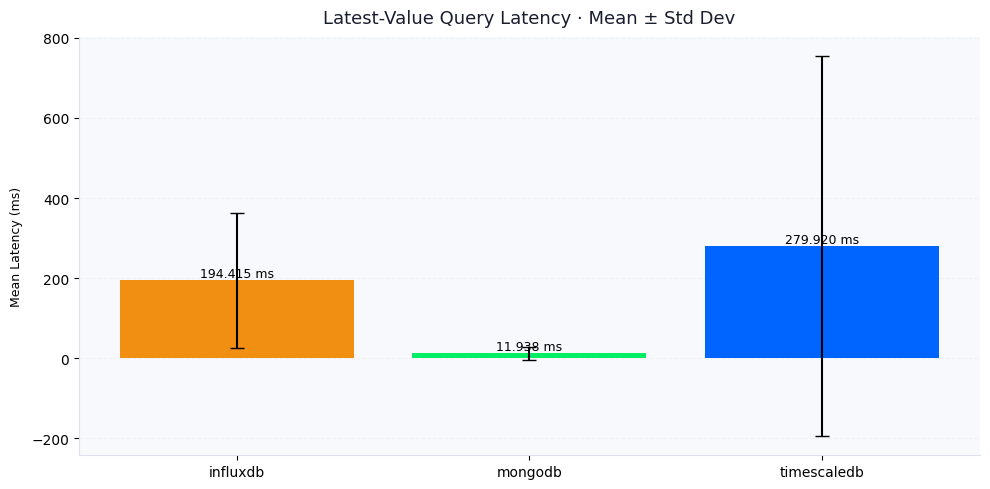

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f8f9fc')

means = summary_df['mean'].values
stds = summary_df['std'].values
colors = [db_color[db] for db in summary_df.index]

bars = ax.bar(summary_df.index, means, yerr=stds, color=colors, capsize=5, zorder=3)

for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.3f} ms', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Mean Latency (ms)', fontsize=9, labelpad=6)
ax.set_title('Latest-Value Query Latency · Mean ± Std Dev', fontsize=13, pad=10, color='#1a1d2e')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#dde1ec')
ax.grid(True, axis='y', alpha=0.4, color='#e4e7f0', linestyle='--', zorder=0)

plt.tight_layout()
plt.show()

## Latency per Parameter — Grouped Bars, All Databases

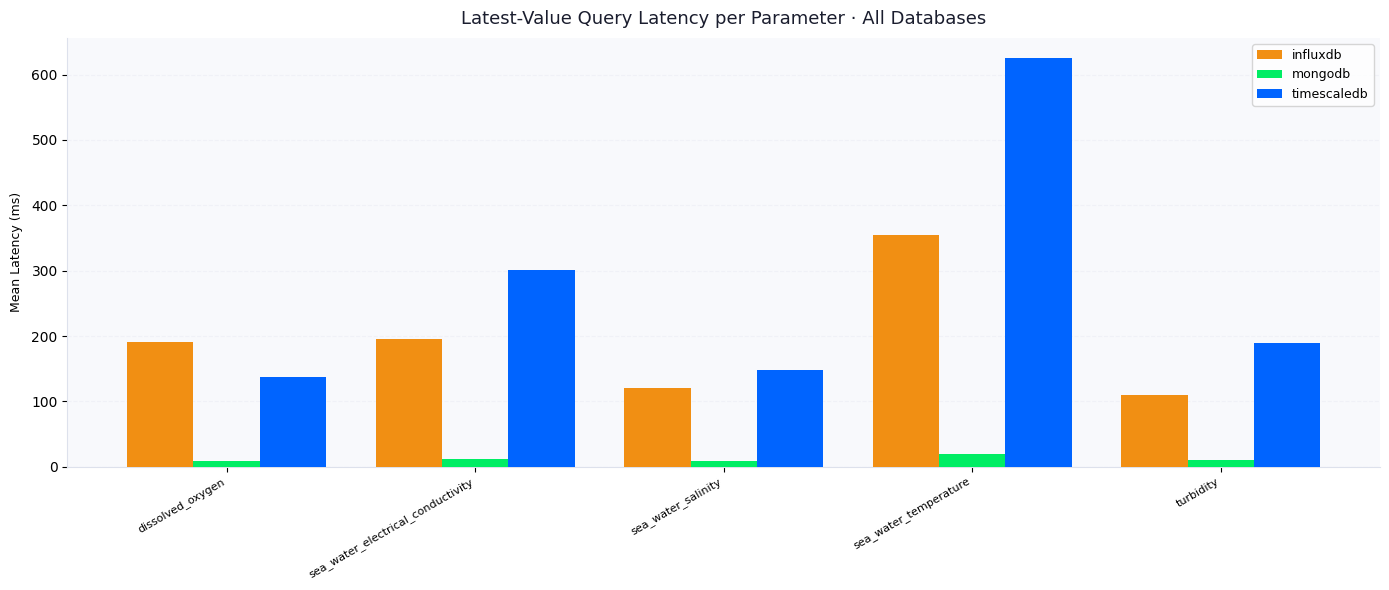

In [26]:
parameters = sorted(df['parameter'].unique())

x = np.arange(len(parameters))
n_dbs = len(db_systems)
bar_width = 0.8 / n_dbs

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f8f9fc')

for i, db in enumerate(db_systems):
    means_per_param = [
        df[(df['database_system'] == db) & (df['parameter'] == p)]['elapsed_ms'].mean()
        for p in parameters
    ]
    offsets = x + i * bar_width - (n_dbs - 1) * bar_width / 2
    ax.bar(offsets, means_per_param, width=bar_width, color=db_color[db], label=db, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(parameters, fontsize=8, rotation=30, ha='right')
ax.set_ylabel('Mean Latency (ms)', fontsize=9, labelpad=6)
ax.set_title('Latest-Value Query Latency per Parameter · All Databases', fontsize=13, pad=10, color='#1a1d2e')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#dde1ec')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, axis='y', alpha=0.4, color='#e4e7f0', linestyle='--', zorder=0)

plt.tight_layout()
plt.show()

# Run-to-Run Variance

C:\Users\yfess\AppData\Local\Temp\ipykernel_18196\3045632376.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_db, labels=db_systems, patch_artist=True, widths=0.5)


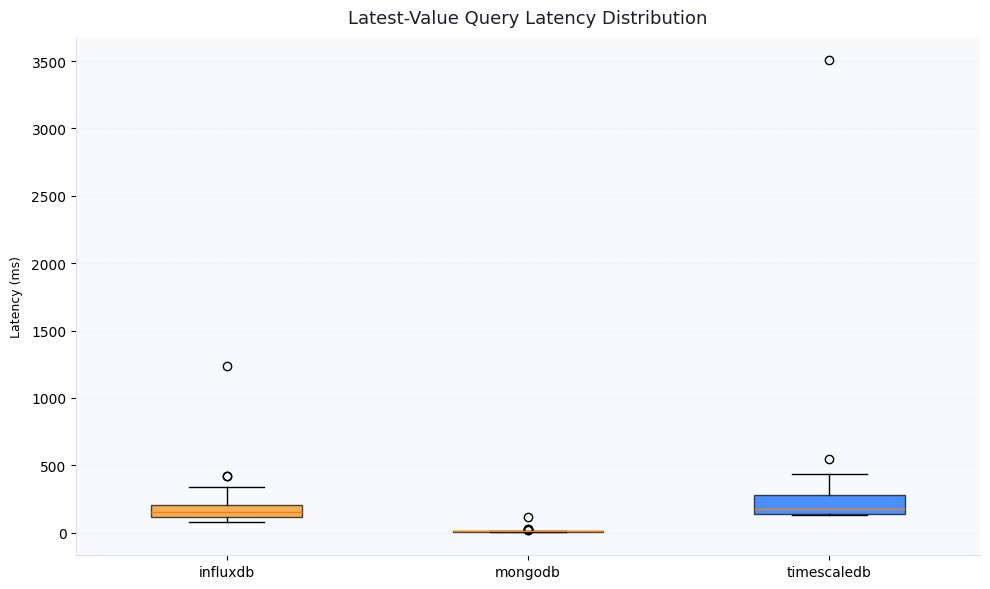

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f8f9fc')

data_by_db = [df[df['database_system'] == db]['elapsed_ms'].values for db in db_systems]

bp = ax.boxplot(data_by_db, labels=db_systems, patch_artist=True, widths=0.5)

for patch, db in zip(bp['boxes'], db_systems):
    patch.set_facecolor(db_color[db])
    patch.set_alpha(0.7)

ax.set_ylabel('Latency (ms)', fontsize=9, labelpad=6)
ax.set_title('Latest-Value Query Latency Distribution', fontsize=13, pad=10, color='#1a1d2e')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#dde1ec')
ax.grid(True, axis='y', alpha=0.4, color='#e4e7f0', linestyle='--', zorder=0)

plt.tight_layout()
plt.show()

# Summary Table

In [28]:
found_check = df.groupby('database_system')['result_found'].agg(['sum', 'count'])
found_check.columns = ['found', 'total']
found_check['all_found'] = found_check['found'] == found_check['total']
found_check

,found,total,all_found
database_system,,,
influxdb,50,50,True
mongodb,50,50,True
timescaledb,50,50,True
